In [2]:
# Gerekli kütüphaneleri içe aktarıyoruz: numpy (sayısal işlemler),
# pandas (veri işleme) ve matplotlib (görselleştirme)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

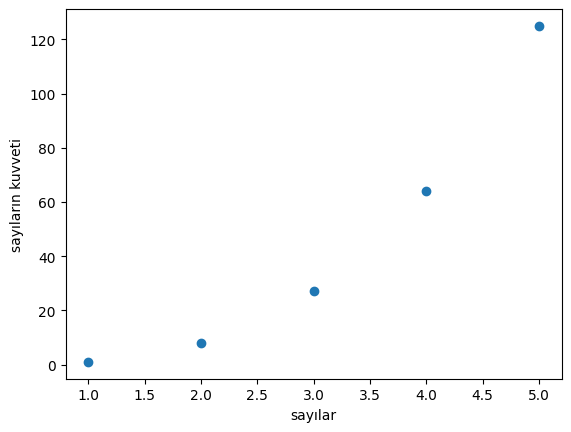

In [3]:
# 1'den 5'e kadar sayılar ile bunların küpü arasındaki ilişkiyi
# nokta grafiği (scatter plot) olarak çiziyoruz
plt.scatter([1,2,3,4,5],[1,8,27,64,125])
plt.xlabel("sayılar")
plt.ylabel("sayıların kuvveti")
plt.show()

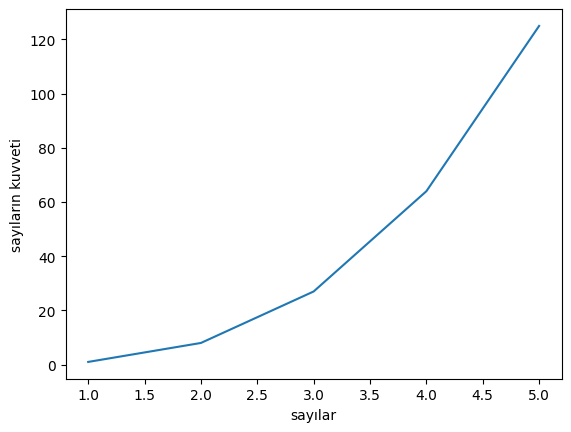

In [4]:
# Aynı veriyi bu sefer çizgi grafiği (line plot) olarak çiziyoruz
plt.plot([1,2,3,4,5],[1,8,27,64,125])
plt.xlabel("sayılar")
plt.ylabel("sayıların kuvveti")
plt.show()

In [5]:
# CSV dosyasından deneyim-maaş verisini okuyoruz ve ilk 5 satırı gösteriyoruz
data = pd.read_csv("/Users/berkecelik/Downloads/tecrube_maas.csv")
data.head()

,Tecrübe,Maaş
0,1.1,3934
1,1.3,4620
2,1.5,3773
3,2.0,4352
4,2.2,3989


In [6]:
# Veri setinin son 5 satırını gösteriyoruz
data.tail()

,Tecrübe,Maaş
25,9.0,10558
26,9.5,11696
27,9.6,11263
28,10.3,12239
29,10.5,12187


In [7]:
# Bağımsız değişkeni (x: deneyim, sklearn için 2D reshape edilmiş),
# bağımlı değişkeni (y: maaş) ve her ikisini birden (z) ayırıyoruz
x = data.iloc[:,0].values.reshape(-1,1)
y = data.iloc[:,1]
z = data.iloc[:,[0,1]]
x

array([[ 1.1],
       [ 1.3],
       [ 1.5],
       [ 2. ],
       [ 2.2],
       [ 2.9],
       [ 3. ],
       [ 3.2],
       [ 3.2],
       [ 3.7],
       [ 3.9],
       [ 4. ],
       [ 4. ],
       [ 4.1],
       [ 4.5],
       [ 4.9],
       [ 5.1],
       [ 5.3],
       [ 5.9],
       [ 6. ],
       [ 6.8],
       [ 7.1],
       [ 7.9],
       [ 8.2],
       [ 8.7],
       [ 9. ],
       [ 9.5],
       [ 9.6],
       [10.3],
       [10.5]])

In [15]:
y

0      3934
1      4620
2      3773
3      4352
4      3989
5      5664
6      6015
7      5444
8      6444
9      5718
10     6321
11     5579
12     5695
13     5708
14     6111
15     6793
16     6602
17     8308
18     8136
19     9394
20     9173
21     9827
22    10130
23    11381
24    10943
25    10558
26    11696
27    11263
28    12239
29    12187
Name: Maaş, dtype: int64

In [16]:
z

,Tecrübe,Maaş
0,1.1,3934
1,1.3,4620
2,1.5,3773
3,2.0,4352
4,2.2,3989
5,2.9,5664
6,3.0,6015
7,3.2,5444
8,3.2,6444
9,3.7,5718


In [8]:
# Veriyi %70 eğitim (train) ve %30 test (test) olarak ikiye ayırıyoruz
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,y,test_size = 0.3)

In [9]:
# Eğitim setindeki x değerlerini (xtrain) görüntülüyoruz
xtrain

array([[ 9.5],
       [10.3],
       [ 1.5],
       [ 4.5],
       [ 3.2],
       [ 3.2],
       [ 5.1],
       [ 9.6],
       [ 7.9],
       [ 4. ],
       [ 8.2],
       [ 9. ],
       [ 4.9],
       [ 6. ],
       [ 3.9],
       [ 7.1],
       [ 4.1],
       [ 5.3],
       [ 2.2],
       [ 5.9],
       [ 2. ]])

In [10]:
# Test setindeki x değerlerini (xtest) görüntülüyoruz
xtest

array([[ 3.7],
       [ 1.3],
       [ 2.9],
       [10.5],
       [ 6.8],
       [ 4. ],
       [ 1.1],
       [ 8.7],
       [ 3. ]])

In [11]:
# x verisini min-max normalizasyonu ile 0-1 aralığına ölçekliyoruz
xnorm = (x-np.min(x)) / (np.max(x) - np.min(x))
xnorm

array([[0.        ],
       [0.0212766 ],
       [0.04255319],
       [0.09574468],
       [0.11702128],
       [0.19148936],
       [0.20212766],
       [0.22340426],
       [0.22340426],
       [0.27659574],
       [0.29787234],
       [0.30851064],
       [0.30851064],
       [0.31914894],
       [0.36170213],
       [0.40425532],
       [0.42553191],
       [0.44680851],
       [0.5106383 ],
       [0.5212766 ],
       [0.60638298],
       [0.63829787],
       [0.72340426],
       [0.75531915],
       [0.80851064],
       [0.84042553],
       [0.89361702],
       [0.90425532],
       [0.9787234 ],
       [1.        ]])

In [12]:
# sklearn'den StandardScaler'ı içe aktarıp bir örnek oluşturuyoruz
# (veriyi ortalaması 0, standart sapması 1 olacak şekilde ölçekleyecek)
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

In [13]:
# StandardScaler'ı eğitim verisine göre fit edip dönüştürüyoruz (xtrain1),
# test verisini ise aynı ölçekle (fit etmeden) dönüştürüyoruz (xtest1)
xtrain1 = sc.fit_transform(xtrain)
xtest1 = sc.transform(xtest)

In [14]:
# Standartlaştırılmış eğitim verisini (xtrain1) görüntülüyoruz
xtrain1

array([[ 1.50346129],
       [ 1.81111232],
       [-1.57304902],
       [-0.41935766],
       [-0.91929058],
       [-0.91929058],
       [-0.18861938],
       [ 1.54191767],
       [ 0.88815923],
       [-0.61163955],
       [ 1.00352836],
       [ 1.31117939],
       [-0.26553214],
       [ 0.15748803],
       [-0.65009593],
       [ 0.5805082 ],
       [-0.57318317],
       [-0.11170662],
       [-1.30385437],
       [ 0.11903165],
       [-1.38076713]])